In [1]:
import numpy as np
import matplotlib.pyplot as plt

from datasets import load_dataset
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

c:\Users\ADMIN\Desktop\Handwriting_CNN_Project\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
dataset = load_dataset("pittawat/letter_recognition")

class_names = dataset["train"].features["label"].names

print("Classes:", class_names)

Classes: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']


*Convert images to NumPy*

In [3]:
def images_to_numpy(split):
    images = np.stack([np.array(img) for img in split["image"]])
    labels = np.array(split["label"])
    return images, labels

X_full, y_full = images_to_numpy(dataset["train"])

print("Images:", X_full.shape)
print("Labels:", y_full.shape)

Images: (26000, 28, 28, 3)
Labels: (26000,)


*Convert RGB to grayscale*

In [4]:
X_gray = np.mean(X_full, axis=-1)

print("After grayscale:", X_gray.shape)

After grayscale: (26000, 28, 28)


*Normalize the images*

In [5]:
X_gray = X_gray.astype("float32") / 255.0

print("Minimum:", X_gray.min())
print("Maximum:", X_gray.max())

Minimum: 0.0
Maximum: 1.0


*sample for K-Means*

In [12]:
X_kmeans = X_gray[:6000]

print("K-Means images:", X_kmeans.shape)

K-Means images: (6000, 28, 28)


*Flatten the images*

In [13]:
X_kmeans_flat = X_kmeans.reshape(
    X_kmeans.shape[0],
    -1
)

print("K-Means input:", X_kmeans_flat.shape)

K-Means input: (6000, 784)


In [14]:
kmeans = KMeans(
    n_clusters=26,
    random_state=42,
    n_init=10
)

cluster_labels = kmeans.fit_predict(X_kmeans_flat)

print("K-Means clustering completed!")
print("Number of clusters:", len(np.unique(cluster_labels)))

K-Means clustering completed!
Number of clusters: 26


*Visualize the clusters*

In [15]:
pca = PCA(n_components=2, random_state=42)

X_pca = pca.fit_transform(X_kmeans_flat)

print("PCA shape:", X_pca.shape)

PCA shape: (6000, 2)


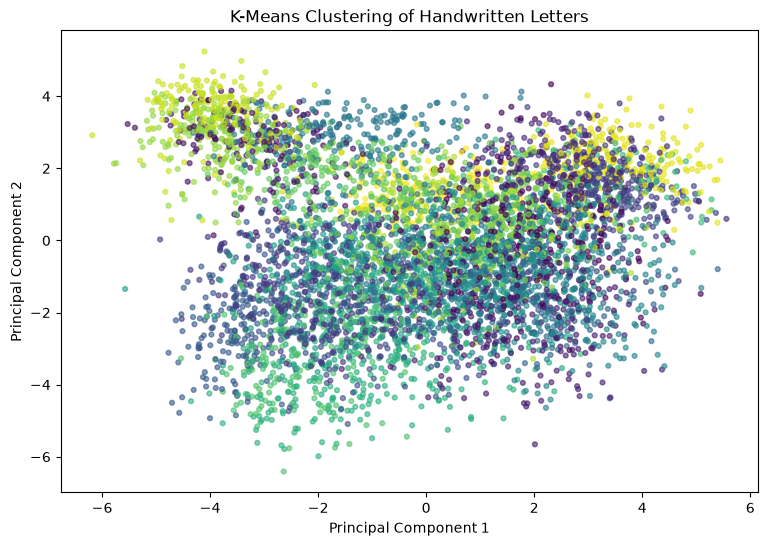

In [16]:
plt.figure(figsize=(9, 6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=cluster_labels,
    s=12,
    alpha=0.6
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K-Means Clustering of Handwritten Letters")

plt.show()

*Calculate Silhouette Score*

In [17]:
silhouette = silhouette_score(
    X_kmeans_flat,
    cluster_labels
)

print(f"Silhouette Score: {silhouette:.4f}")

Silhouette Score: 0.0590
